In [25]:
using Pkg
using CSV
using DataFrames
using Plots
using Printf
using BenchmarkTools
using DelimitedFiles

In [31]:
include("BDCfunctions.jl")

writeIGRcsv (generic function with 1 method)

In [ ]:
#writeIGRcsv(11, 7, 214, 0.1, true, 16e-6, "_10.000000", 13, 214, 0.1, true, 0.003728e-6, "_10.000000")

In [3]:
alpha = 0.015

0.015

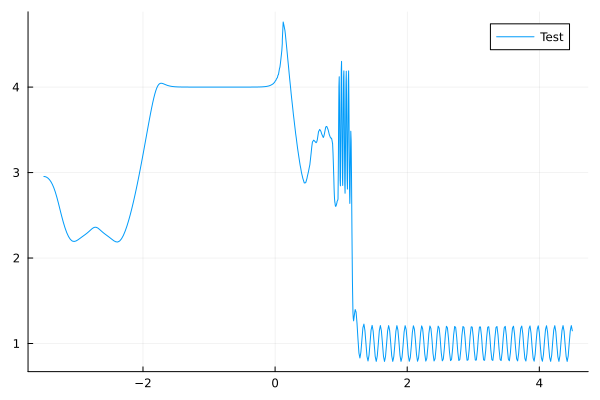

In [33]:
x, rho, v, e, p, igrp = read_all(14, 8, 21433, 0.3, true, 16, "_1.00");
plot(x, rho, lab = "Test")

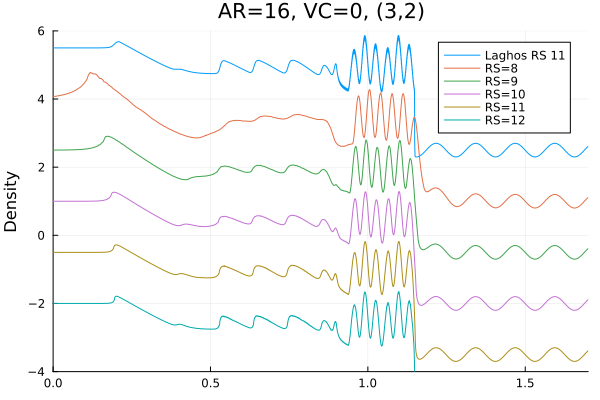

In [225]:
x, rho, v, e, p, igrp = read_all(14, 11, 32413, 0.3, false, 4, "_250.123400");
plot(x, rho .+ 1.5, lab = "Laghos RS 11", legend=:topright)
x, rho, v, e, p, igrp = read_all(14, 8, 32433, 0.3, true, 16, "");
plot!(x, rho, lab = "RS=8", xlim = (0.0,1.7), ylim = (-4,6), title = "AR=16, VC=0, (3,2)")
x, rho, v, e, p, igrp = read_all(14, 9, 32433, 0.3, true, 16, "");
plot!(x, rho .- 1.5, lab = "RS=9", ylab="Density")
x, rho, v, e, p, igrp = read_all(14, 10, 32433, 0.3, true, 16, "");
plot!(x, rho .- 3, lab = "RS=10")
x, rho, v, e, p, igrp = read_all(14, 11, 32433, 0.3, true, 16, "");
plot!(x, rho .- 4.5, lab = "RS=11")
x, rho, v, e, p, igrp = read_all(14, 12, 32433, 0.3, true, 16, "");
plot!(x, rho .- 6, lab = "RS=12")

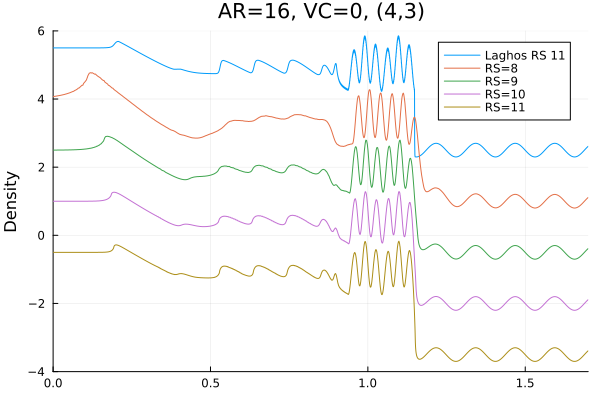

In [231]:
x, rho, v, e, p, igrp = read_all(14, 11, 43413, 0.3, false, 4, "_250.123400");
plot(x, rho .+ 1.5, lab = "Laghos RS 11", legend=:topright)
x, rho, v, e, p, igrp = read_all(14, 8, 43433, 0.3, true, 16, "");
plot!(x, rho, lab = "RS=8", xlim = (0.0,1.7), ylim = (-4,6), title = "AR=16, VC=0, (4,3)")
x, rho, v, e, p, igrp = read_all(14, 9, 43433, 0.3, true, 16, "");
plot!(x, rho .- 1.5, lab = "RS=9", ylab="Density")
x, rho, v, e, p, igrp = read_all(14, 10, 43433, 0.3, true, 16, "");
plot!(x, rho .- 3, lab = "RS=10")
x, rho, v, e, p, igrp = read_all(14, 11, 43433, 0.3, true, 16, "");
plot!(x, rho .- 4.5, lab = "RS=11")

In [ ]:
plot_igr("rho", "RSalpha", 6, 1, 11, 7, 214, 0.1, true, (0,1), (-4,5), -0.5, 16e-6, "_10.000000")
plot!(title = "Mach Test", ylab = "Density")
x, rho, v, e, p, igrp = read_all(11, 13, 214, 0.1, true, 0.003728e-6, "_10.000000");
plot!(x, rho .- 3, lab = "RS 13 0.003728e-6")
x, rho, v, e, p, igrp = read_all(11, 14, 214, 0.1, true, 0.000932e-6, "_10.000000");
plot!(x, rho .- 3.5, lab = "RS 14 0.000932e-6")
x, rho, v, e, p, igrp = read_all(11, 15, 214, 0.1, true, 0.000233e-6, "_10.000000");
plot!(x, rho .- 4, lab = "RS 15 0.000233e-6")

In [ ]:
plot_igr("rho", "RSalpha", 6, 1, 11, 7, 324, 0.1, true, (0,1), (-4,5), -0.5, 16e-6, "_10.000000")
plot!(title = "Mach Test", ylab = "Density")
x, rho, v, e, p, igrp = read_all(11, 13, 324, 0.1, true, 0.003728e-6, "_10.000000");
plot!(x, rho .- 3, lab = "RS 13 0.003728e-6")

In [ ]:
plot_igr("rho", "RSalpha", 6, 1, 11, 7, 434, 0.1, true, (0,1), (-4,5), -0.5, 16e-6, "_10.000000")
plot!(title = "Mach Test", ylab = "Density")
x, rho, v, e, p, igrp = read_all(11, 13, 434, 0.1, true, 0.003728e-6, "_10.000000");
plot!(x, rho .- 3, lab = "RS 13 0.003728e-6")

In [ ]:
x1, rho1, v, e, p, igrp = read_all(11, 14, 214, 0.1, true, 0.000932e-6, "_10.000000");
x2, rho2, v, e, p, igrp = read_all(11, 15, 214, 0.1, true, 0.000233e-6, "_10.000000");

In [ ]:
function AlphaCalc(RS)
    return (RS == 7 ? 16e-6 : (RS == 8 ? 4e-6 : (RS == 9 ? 1e-6 : (RS == 10 ? 0.25e-6 : (RS == 11 ? 0.0625e-6 : 
                        (RS == 12 ? 0.015625e-6 : (RS == 13 ? 0.003728e-6 : (RS == 14 ? 0.000932e-6 : 0.000233e-6))))))))
end

In [ ]:
x, rho, v, e, p, igrp = read_all(14, 7, 4, 0.2, true, 1024e-6, "_40.000000")
plot(x, e, xlim = (0.3,1.2), ylim = (-12,9.5), lab = "Visc 40", ylab="Velocity", title = "Shu Osher Viscosity Test RS 7", 
                               xlab = "dx=0.03=sqrt(α), Order (4,3)", legend =:topleft)
x, rho, v, e, p, igrp = read_all(14, 7, 4, 0.2, true, 1024e-6, "_10.000000")
plot!(x, e .- 2, lab = "Visc 10")
x, rho, v, e, p, igrp = read_all(14, 7, 4, 0.2, true, 1024e-6, "_2.500000")
plot!(x, e .- 4, lab = "Visc 2.5")
x, rho, v, e, p, igrp = read_all(14, 7, 4, 0.2, true, 1024e-6, "_250.123400")
plot!(x, e .- 6, lab = "Laghos Visc")
x, rho, v, e, p, igrp = read_all(14, 7, 4, 0.2, true, 1024e-6, "")
plot!(x, e .- 8, lab = "NO Visc")
x, rho, v, e, p, igrp = read_all(14, 7, 4, 0.2, false, 1024e-6, "_250.123400")
plot!(x, e .- 11, lab = "Laghos Visc + NOIGR")
x, rho, v, e, p, igrp = read_all(14, 11, 4, 0.2, true, 4e-6, "_10.000000")
plot!(x, e .- 13, lab = "RS 11 Visc 10")